In [2]:
import tensorflow as tf
import os 
import numpy as np
from keras.preprocessing.image import load_img,img_to_array,array_to_img
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.callbacks import Callback,EarlyStopping

In [4]:
n_of_image,label_name = 3250,['Grape Black Rot', 'Grape Esca', 'Grape Leaf blight', 'Grape healthy']
                              
img,label,img_size = [],[],(150,150)

path_dir = 'D:/Projects/leaf-diseases-detect-main/Media/lackrot'
os.chdir(path_dir)
img_path_list = os.listdir(path_dir)
for len_no,img_path in enumerate(img_path_list):
  if len_no == n_of_image:break
  else:
    img.append(img_to_array(load_img(img_path,target_size=img_size))/255)
    label.append(0) # Grape___Black_rot

path_dir = 'D:/Projects/leaf-diseases-detect-main/Media/esca'
os.chdir(path_dir)
img_path_list = os.listdir(path_dir)
for len_no,img_path in enumerate(img_path_list):
  if len_no == n_of_image:break
  else:
    img.append(img_to_array(load_img(img_path,target_size=img_size))/255)
    label.append(1) # Grape___Esca_(Black_Measles)

path_dir = 'D:/Projects/leaf-diseases-detect-main/Media/healthy leaf'
os.chdir(path_dir)
img_path_list = os.listdir(path_dir)
for len_no,img_path in enumerate(img_path_list):
  if len_no == n_of_image:break
  else:
    img.append(img_to_array(load_img(img_path,target_size=img_size))/255)
    label.append(2) # Grape___healthy

path_dir = 'D:/Projects/leaf-diseases-detect-main/Media/leaf blight'
os.chdir(path_dir)
img_path_list = os.listdir(path_dir)
for len_no,img_path in enumerate(img_path_list):
  if len_no == n_of_image:break
  else:
    img.append(img_to_array(load_img(img_path,target_size=img_size))/255)
    label.append(3) # Grape___Leaf_blight_(Isariopsis_Leaf_Spot)



img,label = np.array(img),np.array(label)

In [5]:
IMG_SHAPE = img_size + (3,)  # Add the number of channels (3 for RGB)
vgg = tf.keras.applications.vgg16.VGG16(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)

In [6]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
vgg.trainable = False

In [8]:
import pandas as pd

pd.set_option('max_colwidth', None)

layer_vgg = [(layer, layer.name, layer.trainable) for layer in vgg.layers]
pd.DataFrame(layer_vgg, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])

,Layer Type,Layer Name,Layer Trainable
0,"<InputLayer name=input_layer, built=True>",input_layer,False
1,"<Conv2D name=block1_conv1, built=True>",block1_conv1,False
2,"<Conv2D name=block1_conv2, built=True>",block1_conv2,False
3,"<MaxPooling2D name=block1_pool, built=True>",block1_pool,False
4,"<Conv2D name=block2_conv1, built=True>",block2_conv1,False
5,"<Conv2D name=block2_conv2, built=True>",block2_conv2,False
6,"<MaxPooling2D name=block2_pool, built=True>",block2_pool,False
7,"<Conv2D name=block3_conv1, built=True>",block3_conv1,False
8,"<Conv2D name=block3_conv2, built=True>",block3_conv2,False
9,"<Conv2D name=block3_conv3, built=True>",block3_conv3,False


In [9]:
average_pool = tf.keras.layers.GlobalAveragePooling2D()

prediction = tf.keras.Sequential([
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(4,activation='softmax')           
])


tl_model = tf.keras.Sequential([
  vgg,
  average_pool,
  prediction,
  ])

In [10]:
tl_model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
img,img_test,label,label_test = train_test_split(img,label,test_size=0.25,random_state=10)

In [12]:
os.chdir('D:/Projects/leaf-diseases-detect-main/Training/model')

In [13]:
class mycallback(Callback):
  def on_train_end(self,epoch,log={}):
    if (log.get('val_accuracy') >= '0.90'):
      print('Reached 90.9% accuracy so cancelling training')
      self.model.stop_training = True

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
          
castom_call = mycallback()

early_stop = EarlyStopping(monitor='val_accuracy', patience=3)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_ckpt = ModelCheckpoint('best_model.h5', save_best_only=True)

tl_model.fit(
    img, to_categorical(label),
    epochs=5,
    validation_data=(img_test, to_categorical(label_test)),
    callbacks=[model_ckpt, early_stop]
)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4062 - loss: 1.3076

76/76 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.4081 - loss: 1.3055 - val_accuracy: 0.7015 - val_loss: 0.9161
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7469 - loss: 0.8682

76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7468 - loss: 0.8677 - val_accuracy: 0.7923 - val_loss: 0.7317
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7830 - loss: 0.7012

76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7829 - loss: 0.7010 - val_accuracy: 0.8271 - val_loss: 0.6270
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8315 - loss: 0.6079

76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8313 - loss: 0.6078 - val_accuracy: 0.8470 - val_loss: 0.5562
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8259 - loss: 0.5502

76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8260 - loss: 0.5500 - val_accuracy: 0.8321 - val_loss: 0.5183


In [14]:
tl_model.save('D:/Leaf Deases(96,88).h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


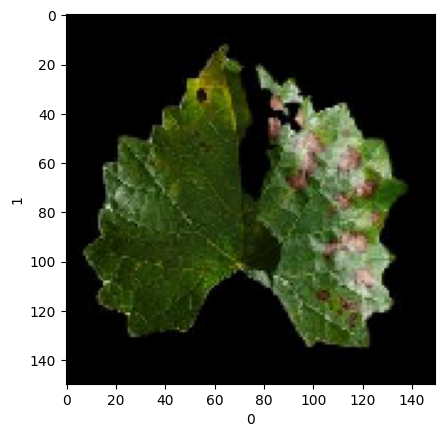

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


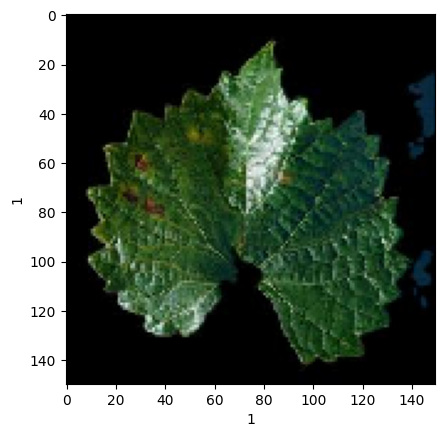

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


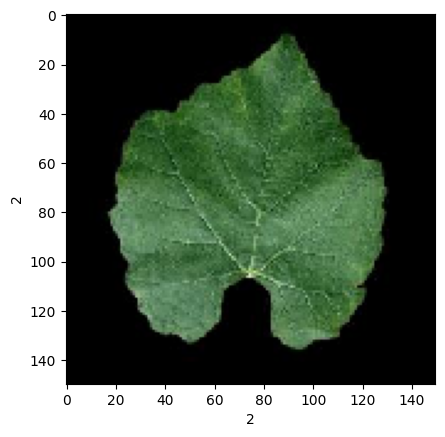

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


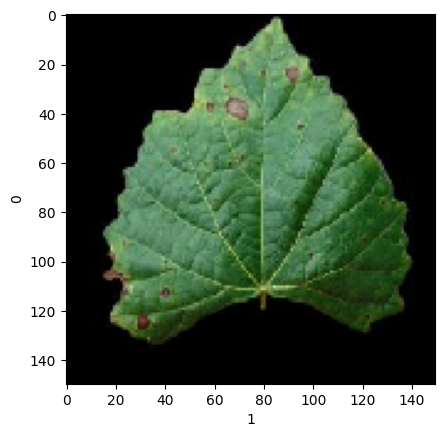

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


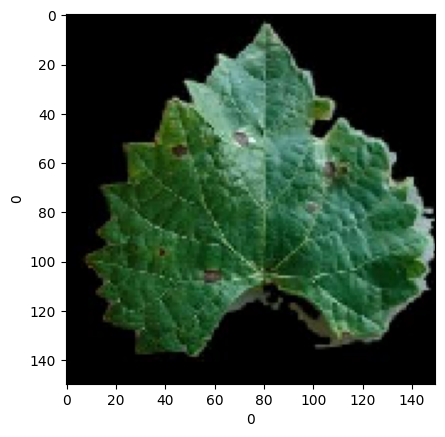

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


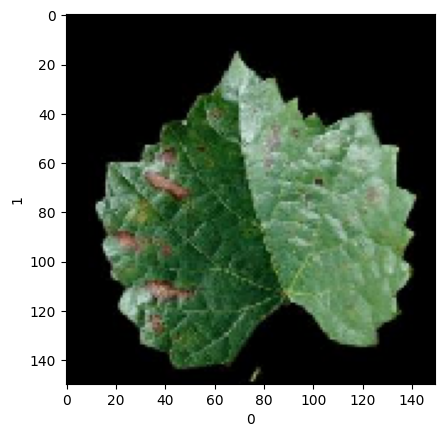

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


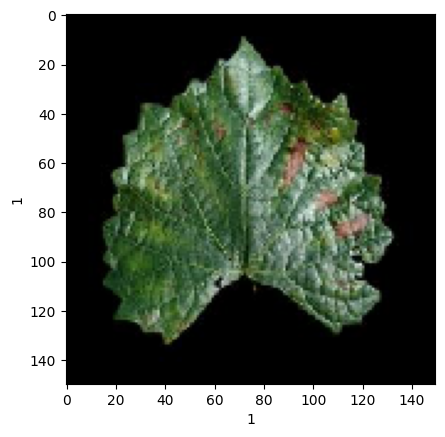

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


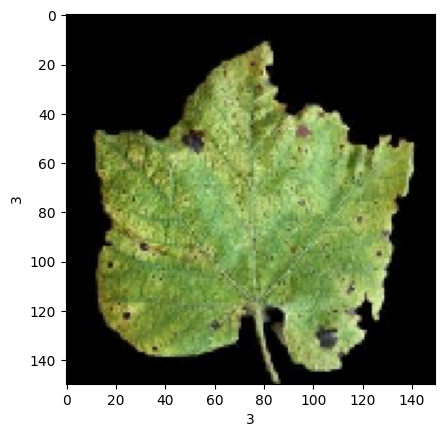

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


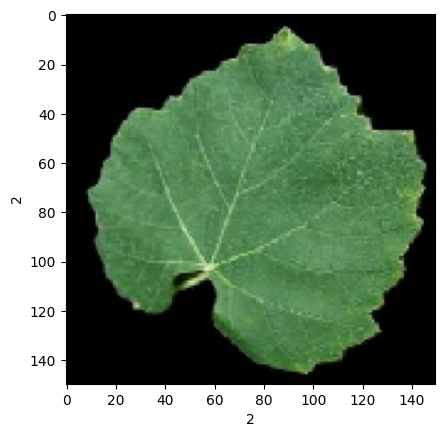

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


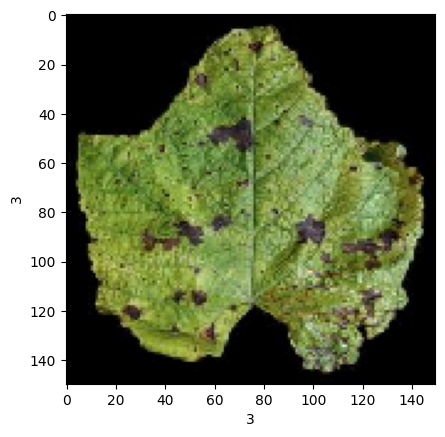

In [21]:
for i in range(0,10):
    plt.imshow(img_test[i])
    plt.ylabel(label_test[i])
    img = img_test[i]
    pr = tl_model.predict(img.reshape((1,)+img.shape)) 
    plt.xlabel(np.argmax(pr))
    plt.show()
    plt.close()